# Cài đặt các Thư viện sử dụng

In [1]:
import pandas as pd
import re
import matplotlib.pyplot as plt
from underthesea import word_tokenize
import os

In [2]:
import warnings
warnings.filterwarnings("ignore")

# Cài đặt hiển thị dataFrame

In [3]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

# Đọc dữ liệu


- vn_news_223_tdlfr.csv là file chứa news cần xử lý
- vietnamese-stopwords.txt chứa các stop word cần xử lý

In [4]:

file = os.path.join("../../Data_Train", "Vietnamese.csv")
data_df = pd.read_csv(file, encoding = 'utf-8')

file_stopword = os.path.join("../../Data_Train", "vietnamese-stopwords-dash.txt")
with open(file_stopword, 'r', encoding='utf-8') as file:
    stopwords = file.read().split('\n')

# Khám phá dữ liệu

## Mẫu dữ liệu

In [5]:
data_df.sample(1)

title  \
4787  Tổng Bí thư Tô Lâm: Lấy hạnh phúc của nhân dân là niềm vui lẽ sống   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                          

## Xem thông tin

In [6]:
data_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12600 entries, 0 to 12599
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   title   12600 non-null  object
 1   text    12600 non-null  object
 2   label   12600 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 295.4+ KB


In [7]:
data_df["title_length"] = data_df["title"].apply(lambda title: len(title.split(" ")))
data_df["text_length"] = data_df["text"].apply(lambda text: len(text.split(" ")))

In [8]:
data_df[["title_length", "text_length"]].describe()

,title_length,text_length
count,12600.000000,12600.000000
mean,13.281905,913.570556
std,4.446797,828.093960
min,1.000000,52.000000
25%,10.000000,384.000000
50%,14.000000,699.000000
75%,16.000000,1174.000000
max,47.000000,15495.000000


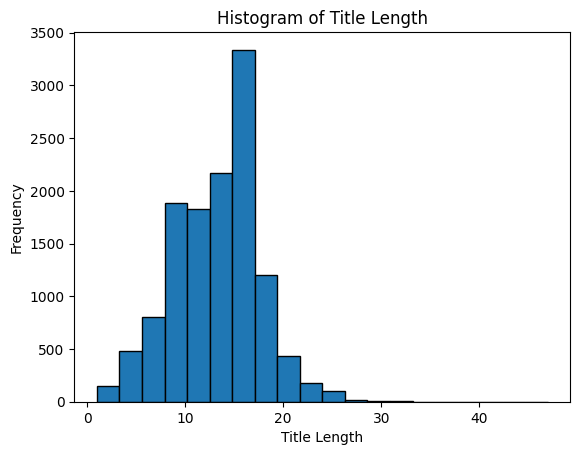

In [9]:
data_df["title_length"].plot(kind="hist", bins=20, edgecolor='black')
plt.title('Histogram of Title Length')
plt.xlabel('Title Length')
plt.ylabel('Frequency')
plt.show()

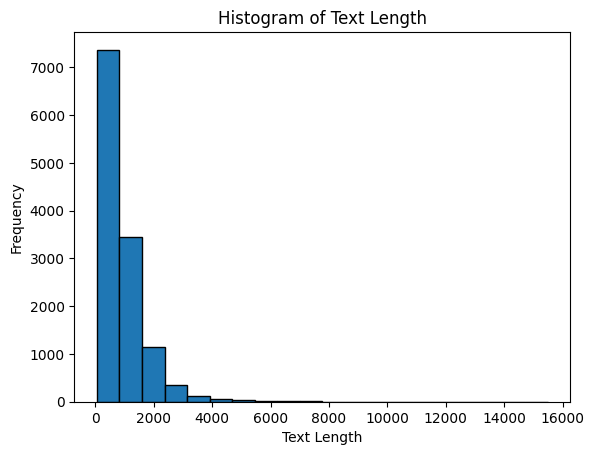

In [10]:
data_df["text_length"].plot(kind="hist", bins=20, edgecolor='black')
plt.title('Histogram of Text Length')
plt.xlabel('Text Length')
plt.ylabel('Frequency')
plt.show()

## Xem mô tả

In [11]:
data_df.describe().round(1)

,label,title_length,text_length
count,12600.0,12600.0,12600.0
mean,0.5,13.3,913.6
std,0.5,4.4,828.1
min,0.0,1.0,52.0
25%,0.0,10.0,384.0
50%,0.0,14.0,699.0
75%,1.0,16.0,1174.0
max,1.0,47.0,15495.0


## Xem số dòng và số cột của dữ liệu

In [12]:
num_rows=data_df.shape[0]
num_cols=data_df.shape[1]
print(num_rows)
print(num_cols)

12600
5


## ý nghĩa của các dòng

### Kiểm tra dữ liệu có bị lặp ?

In [13]:
dup=data_df.index.duplicated().sum()
dup

0

### ý nghĩa các cột

- text: nội dung của tin tức
- domain: đường dẫn đến trang web chứa tin tức 
- label: nhãn phân biệt tin giả hay tin thật

#### Cột có dtype là object nghĩa là sao?

- Trong Pandas, kiểu dữ liệu object thường ám chỉ chuỗi, nhưng thật ra kiểu dữ liệu object có thể chứa một đối tượng bất kỳ trong Python (vì thật ra ở bên dưới kiểu dữ liệu object chứa địa chỉ).
- Nếu một cột trong dataframe có dtype là object thì có thể các phần tử trong cột này sẽ có kiểu dữ liệu khác nhau
- Để biết được kiểu dữ liệu thật sự của các phần tử trong cột này thì ta phải truy xuất vào từng phần tử. Ta muốn xem thử trong nội bộ mỗi cột này có các kiểu dữ liệu nào

In [14]:
def open_object_dtype(s):
    dtypes = set()
    s=s.apply(type)
    dtypes.update(s.unique().tolist())
    return dtypes

In [15]:
open_object_dtype(data_df['title'])

{str}

In [16]:
open_object_dtype(data_df['text'])

{str}

In [17]:
open_object_dtype(data_df['label'])

{int}

### Dữ liệu có bị thiếu không?

In [18]:
data_df.isnull().sum()

title           0
text            0
label           0
title_length    0
text_length     0
dtype: int64

#### Kiểm tra phân bố các class có chênh lệch không?

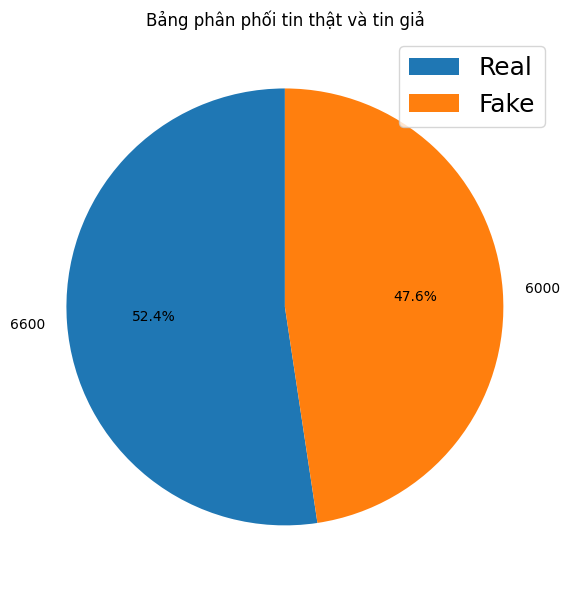

In [19]:
# data quantity chart
def quantity_chart():
    counts_df1 = data_df['label'].value_counts()

    plt.figure(figsize=(6, 6))

    plt.pie(counts_df1, labels=counts_df1, autopct='%1.1f%%', startangle=90)
    plt.title('Bảng phân phối tin thật và tin giả')

    labels = ['Real' if label == 0 else 'Fake' for label in counts_df1.index]
    plt.legend(labels=labels, loc="best", fontsize=18)  # Tăng kích thước nhãn trong chú thích
    plt.tight_layout()
    plt.show()
quantity_chart()

#### Các thông tin thống kê

##### Chiều dài trung bình mỗi record là bao nhiêu?

In [20]:
len_sum=0
for i in data_df['text']:
    len_sum+=len(i)
len_avg=len_sum/data_df['text'].count()
len_avg

4070.9562698412697

##### Record dài nhất là bao nhiêu?

In [21]:
max_len=0
for i in data_df['text']:
    if len(i)>max_len:
        max_len=len(i)
max_len

68695

##### Record ngắn nhất là bao nhiêu?

In [22]:
min_len=len(data_df['text'][0])
for i in data_df['text']:
    if len(i)<min_len:
        min_len=len(i)
min_len

300

### Tiền xử lí văn bản tiếng việt

#### Loại bỏ các đường link và các dấu câu, lowercase

In [23]:
from pyvi import ViTokenizer
from collections import Counter

In [24]:
def wordopt(text):
    text = text.lower()
    text = re.sub('https?:\/\/.*[\r\n]*', ' ', text)
    text = re.sub('[^\w\s]', ' ', text) 
    text = re.sub('\n', ' ', text)
    return text

#delete numbers
def delete_numbers(text):
    return re.sub(r'\d+', ' ', text)
#lower case
def lower(text):
    return text.lower()

#delete special characters
def remove_special_characters(text):
    ## Remove punctuations
    text = re.sub('[%s]' % re.escape("""!–"#$%&'()*+,،-./:;<=>؟?@[\]^`{|}~“”…"""), ' ', text)
    text = text.replace('؛',"", )
    text = re.sub('\s+', ' ', text)
    text =  " ".join(text.split())
    return text.strip()
#delete stop words
def remove_stopwords(text):
    clean_tokens = ' '.join([word for word in text.split() if word not in stopwords])
    return clean_tokens

def preprocess_nostop(text):
    text = delete_numbers(text)
    text = lower(text)
    text = remove_special_characters(text)
    return text


In [25]:
# Compound Vietnamese word
def tokenizerVN(text):
    return ViTokenizer.tokenize(text)
# Tokenizer
def tokenizer(text):
    return word_tokenize(text)
# Count token
def count_token(text):
    word = tokenizerVN(str(text))
    return len(word.split())
# Word Cloud
def top_count(dt):
    top = Counter([item for sublist in data_df[dt].apply(lambda x:str(x).split()) for item in sublist])
    temp = pd.DataFrame(top.most_common(50))
    temp.columns = ['Common_words','count']
    temp.style.background_gradient(cmap='Blues')
    return temp

In [26]:
data_df['article'] = ' |title| '+ data_df["title"] +' |text| '+  data_df["text"] 

In [27]:
data_df.head(1)

title  \
0  Cấm biển di dân khỏi vùng nguy hiểm từ Quảng Ninh đến Nghệ An   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                  

In [28]:
data_df['Compound_Content'] = data_df['article'].apply(tokenizerVN)

In [29]:
data_df['Compound_Content_SW'] = data_df['Compound_Content'].apply(preprocess_nostop)

In [30]:
data_df.head(1)

title  \
0  Cấm biển di dân khỏi vùng nguy hiểm từ Quảng Ninh đến Nghệ An   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                  

# Vector hóa

#### Tokenizer

In [31]:
def tokenize(sentence):
    return tokenizerVN(sentence).split()


### Mô hình hóa

- Chuyển đoạn văn tiếng Việt về vector
- với các tham số là danh sách stopwords tiếng Việt
- và tokenizer tách từ tiếng Việt

In [32]:
from sklearn.metrics import classification_report,accuracy_score
from sklearn.model_selection import train_test_split
import joblib

In [33]:
X = data_df['Compound_Content_SW']
y = data_df["label"]
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=0.25,
                                                   random_state=30)

In [34]:
from sklearn.ensemble import RandomForestClassifier

# Vector

In [35]:
model_vector_CV = os.path.join("../../Vector/Vietnamese/CV", "Vietnamese_vectorizer_CV.joblib")
model_RFC_CV = os.path.join("../../Vector/Vietnamese/CV", "Vietnamese_RFC_model_CV.joblib")


In [36]:
model_vector_TF = os.path.join("../../Vector/Vietnamese/TF", "Vietnamese_vectorizer_TF.joblib")
model_RFC_TF = os.path.join("../../Vector/Vietnamese/TF", "Vietnamese_RFC_model_TF.joblib")

In [37]:
model_vector_W2V = os.path.join("../../Vector/Vietnamese/W2V", "Vietnamese_vectorizer_W2V.joblib")
model_RFC_W2V = os.path.join("../../Vector/Vietnamese/W2V", "Vietnamese_RFC_model_W2V.joblib")

In [38]:
model_vector_D2V = os.path.join("../../Vector/Vietnamese/D2V", "Vietnamese_vectorizer_D2V.joblib")
model_RFC_D2V = os.path.join("../../Vector/Vietnamese/D2V", "Vietnamese_RFC_model_D2V.joblib")

In [39]:
from sklearn.feature_extraction.text import CountVectorizer

from sklearn.feature_extraction.text import TfidfVectorizer

from gensim.models import Word2Vec
import numpy as np

from gensim.models import Doc2Vec
from gensim.models.doc2vec import TaggedDocument

## CountVectorizer

In [40]:
vectorizerCV = CountVectorizer(
    stop_words = stopwords,
    tokenizer = tokenize,
)

In [41]:
Xv_trainCV = vectorizerCV.fit_transform(X_train)
Xv_testCV = vectorizerCV.transform(X_test)

## TfidfVectorizer

In [42]:
vectorizerTF = TfidfVectorizer(max_features=50000,
                               tokenizer=tokenize,
                                stop_words=stopwords,
                                min_df=0.002, max_df=0.5, 
                                use_idf=True, ngram_range=(1,3))

In [43]:
Xv_trainTF = vectorizerTF.fit_transform(X_train)
Xv_testTF = vectorizerTF.transform(X_test)

## Word2Vec

In [44]:
def makeWords(sentences):
    wordList = []
    for sentence in sentences:
        words = sentence.split(' ')
        wordList.append(words)
    return wordList

words_train_W2V = makeWords(X_train)
words_test_W2V = makeWords(X_test)

In [45]:
# Train the Word2Vec model on the tokenized training sentences
vectorizerW2V = Word2Vec(
    sentences=words_train_W2V,
    vector_size=100,
    window=5,
    min_count=1,
    workers=4,
    sg=0,
    epochs=20
)

In [46]:
# Function to calculate the average Word2Vec vector for each sentence
def sentence_vector(sentence, model):
    # Get vectors for words in the sentence if they exist in the vocabulary
    vectors = [model.wv[word] for word in sentence if word in model.wv]
    if len(vectors) > 0:
        # Calculate the mean of the word vectors for the sentence
        return np.mean(vectors, axis=0)
    else:
        # Return a zero vector if no words in the sentence are in the vocabulary
        return np.zeros(model.vector_size)

In [47]:
Xv_trainW2V = np.array([sentence_vector(sentence, vectorizerW2V) for sentence in words_train_W2V])
Xv_testW2V = np.array([sentence_vector(sentence, vectorizerW2V) for sentence in words_test_W2V])

## Doc2Vec

In [48]:
documents = [TaggedDocument(doc.split(), [i]) for i, doc in enumerate(X_train)]

In [49]:
vectorizerD2V = Doc2Vec(
    documents=documents,  # Truyền documents trực tiếp
    vector_size=100,      # Kích thước vector
    window=5,             # Kích thước cửa sổ ngữ cảnh
    min_count=1,          # Bỏ qua từ xuất hiện ít hơn min_count
    workers=4,            # Số luồng để huấn luyện
    epochs=20             # Số lần lặp để huấn luyện
)

In [50]:
Xv_trainD2V = [vectorizerD2V.infer_vector(doc.split()) for doc in X_train]
Xv_testD2V = [vectorizerD2V.infer_vector(doc.split()) for doc in X_test]

## Save model

In [51]:
# joblib.dump(vectorizerCV, model_vector_CV)
# joblib.dump(vectorizerTF, model_vector_TF)
# joblib.dump(vectorizerW2V,model_vector_W2V)
# joblib.dump(vectorizerD2V, model_vector_D2V)

# Train RandomForestClassifier

In [52]:
from sklearn.metrics import precision_score, recall_score, accuracy_score, f1_score, confusion_matrix

In [53]:
rfc_cv = RandomForestClassifier(random_state=42)
rfc_tf = RandomForestClassifier(random_state=42)
rfc_w2v = RandomForestClassifier(random_state=42)
rfc_d2v = RandomForestClassifier(random_state=42)

## CountVectorizer

In [54]:
rfc_cv.fit(Xv_trainCV,y_train)
pred_rfc_cv = rfc_cv.predict(Xv_testCV)

## TfidfVectorizer

In [55]:
rfc_tf.fit(Xv_trainTF,y_train)
pred_rfc_tf = rfc_tf.predict(Xv_testTF)

## Word2Vec

In [56]:
rfc_w2v.fit(Xv_trainW2V, y_train)
pred_rfc_w2v = rfc_w2v.predict(Xv_testW2V)

## Doc2Vec

In [57]:
rfc_d2v.fit(Xv_trainD2V, y_train)
pred_rfc_d2v = rfc_d2v.predict(Xv_testD2V)

# evaluate_model

In [58]:
def evaluate_model(y_true, y_pred, name_model):
    """
    Tính toán các chỉ số đánh giá mô hình.
    Args:
        y_true (array-like): Nhãn thực tế.
        y_pred (array-like): Nhãn dự đoán.

    Returns:
        dict: Các chỉ số bao gồm Precision, Recall, Accuracy, F1-score, FPR, FNR.
    """
    # Precision (PPV)
    precision = precision_score(y_true, y_pred, pos_label=1)
    
    # Recall (TPR)
    recall = recall_score(y_true, y_pred, pos_label=1)
    
    # Accuracy (ACC)
    accuracy = accuracy_score(y_true, y_pred)
    
    # F1-Score
    f1 = f1_score(y_true, y_pred)
    
    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    
    # False Positive Rate (FPR): FP / (FP + TN)
    fpr = cm[0][1] / (cm[0][1] + cm[0][0]) if (cm[0][1] + cm[0][0]) > 0 else 0.0
    
    # False Negative Rate (FNR): FN / (FN + TP)
    fnr = cm[1][0] / (cm[1][0] + cm[1][1]) if (cm[1][0] + cm[1][1]) > 0 else 0.0
    
    # Kết quả
    metrics = {
        "Precision (PPV)": precision,
        "Recall (TPR)": recall,
        "Accuracy (ACC)": accuracy,
        "F1-Score": f1,
        "False Positive Rate (FPR)": fpr,
        "False Negative Rate (FNR)": fnr,
    }
    metrics_df = pd.DataFrame(metrics.items(), columns=["Method", "Value"])
    path_evaluate = os.path.join("../../Evaluate/VietNamese", f"Vietnamese_Evaluate_{name_model}.csv")
    metrics_df.to_csv(path_evaluate, index=False)

## Predict model

In [59]:
from sklearn.metrics import confusion_matrix  
import seaborn as sns

In [60]:
accuracy = accuracy_score(y_test, pred_rfc_cv) 
print(accuracy)
print('-------------------\n')

print(classification_report(y_true=y_test, y_pred=pred_rfc_cv))
print('-------------------\n')

evaluate_model(y_true=y_test, y_pred=pred_rfc_cv,name_model="rfc_cv")

0.9723809523809523
-------------------

              precision    recall  f1-score   support

           0       0.97      0.98      0.97      1586
           1       0.98      0.97      0.97      1564

    accuracy                           0.97      3150
   macro avg       0.97      0.97      0.97      3150
weighted avg       0.97      0.97      0.97      3150

-------------------



[[1552   34]
 [  53 1511]]


<Axes: >

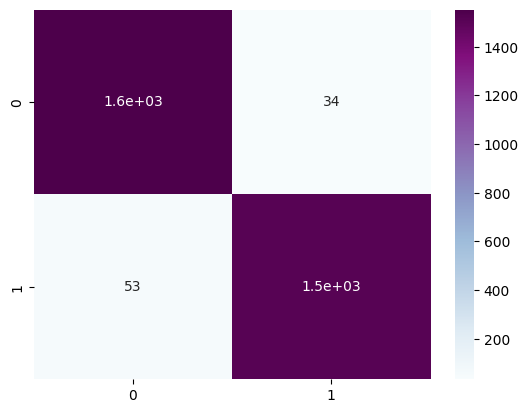

In [61]:
cm = confusion_matrix(y_test,pred_rfc_cv)
print(cm)
sns.heatmap(cm,cmap="BuPu",annot=True)

In [62]:
accuracy = accuracy_score(y_test, pred_rfc_tf) 
print(accuracy)
print('-------------------\n')

print(classification_report(y_true=y_test, y_pred=pred_rfc_tf))
print('-------------------\n')

evaluate_model(y_true=y_test, y_pred=pred_rfc_tf,name_model="rfc_tf")

0.9765079365079365
-------------------

              precision    recall  f1-score   support

           0       0.97      0.98      0.98      1586
           1       0.98      0.97      0.98      1564

    accuracy                           0.98      3150
   macro avg       0.98      0.98      0.98      3150
weighted avg       0.98      0.98      0.98      3150

-------------------



[[1555   31]
 [  43 1521]]


<Axes: >

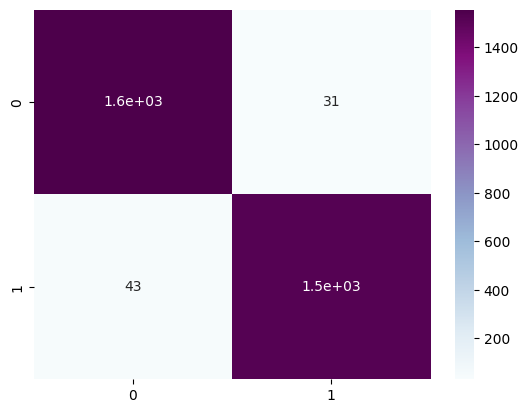

In [63]:
cm = confusion_matrix(y_test,pred_rfc_tf)
print(cm)
sns.heatmap(cm,cmap="BuPu",annot=True)

In [64]:
accuracy = accuracy_score(y_test, pred_rfc_w2v) 
print(accuracy)
print('-------------------\n')

print(classification_report(y_true=y_test, y_pred=pred_rfc_w2v))
print('-------------------\n')

evaluate_model(y_true=y_test, y_pred=pred_rfc_w2v,name_model="rfc_w2v")


0.9685714285714285
-------------------

              precision    recall  f1-score   support

           0       0.96      0.97      0.97      1586
           1       0.97      0.96      0.97      1564

    accuracy                           0.97      3150
   macro avg       0.97      0.97      0.97      3150
weighted avg       0.97      0.97      0.97      3150

-------------------



[[1545   41]
 [  58 1506]]


<Axes: >

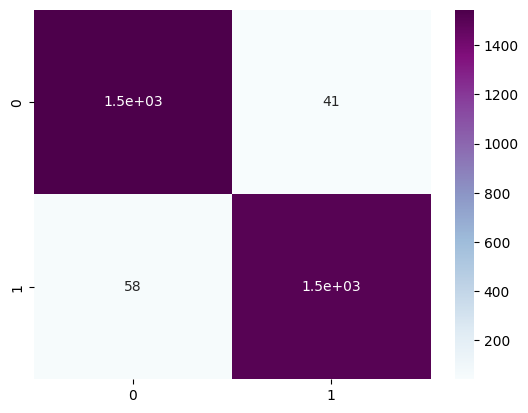

In [65]:
cm = confusion_matrix(y_test,pred_rfc_w2v)
print(cm)
sns.heatmap(cm,cmap="BuPu",annot=True)

In [66]:
accuracy = accuracy_score(y_test, pred_rfc_d2v) 
print(accuracy)
print('-------------------\n')

print(classification_report(y_true=y_test, y_pred=pred_rfc_d2v))
print('-------------------\n')

evaluate_model(y_true=y_test, y_pred=pred_rfc_d2v,name_model="rfc_d2v")

0.9619047619047619
-------------------

              precision    recall  f1-score   support

           0       0.96      0.96      0.96      1586
           1       0.96      0.96      0.96      1564

    accuracy                           0.96      3150
   macro avg       0.96      0.96      0.96      3150
weighted avg       0.96      0.96      0.96      3150

-------------------



[[1527   59]
 [  61 1503]]


<Axes: >

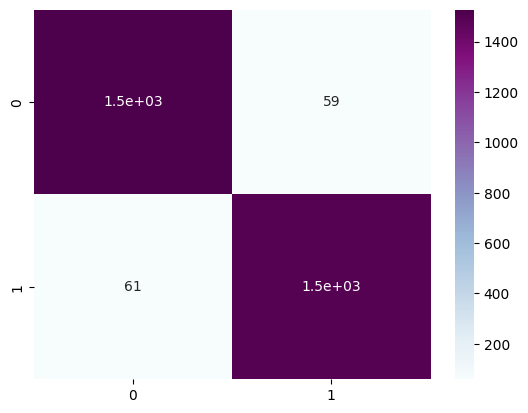

In [67]:
cm = confusion_matrix(y_test,pred_rfc_d2v)
print(cm)
sns.heatmap(cm,cmap="BuPu",annot=True)

# Save model RFC

In [68]:
# joblib.dump(rfc_cv, model_RFC_CV)
# joblib.dump(rfc_tf, model_RFC_TF)
# joblib.dump(vectorizerW2V,model_vector_W2V)
# joblib.dump(rfc_d2v, model_RFC_D2V)

# Vector TF-IDF

In [69]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import MultinomialNB


In [70]:
nb_model = MultinomialNB()
nb_model.fit(Xv_trainTF, y_train)
y_pred_nb = nb_model.predict(Xv_testTF)
print("Naive Bayes Results")
print(classification_report(y_test, y_pred_nb))


Naive Bayes Results
              precision    recall  f1-score   support

           0       0.95      0.95      0.95      1586
           1       0.95      0.95      0.95      1564

    accuracy                           0.95      3150
   macro avg       0.95      0.95      0.95      3150
weighted avg       0.95      0.95      0.95      3150



[[1514   72]
 [  72 1492]]


<Axes: >

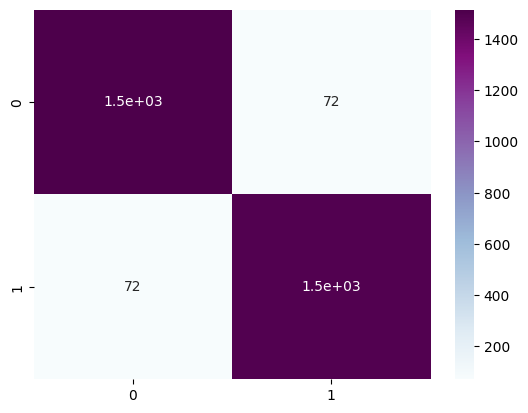

In [71]:
cm = confusion_matrix(y_test,y_pred_nb)
print(cm)
sns.heatmap(cm,cmap="BuPu",annot=True)

In [72]:
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(Xv_trainTF, y_train)
y_pred_dt = dt_model.predict(Xv_testTF)
print("Decision Tree Results")
print(classification_report(y_test, y_pred_dt))


Decision Tree Results
              precision    recall  f1-score   support

           0       0.92      0.94      0.93      1586
           1       0.94      0.91      0.92      1564

    accuracy                           0.92      3150
   macro avg       0.93      0.92      0.92      3150
weighted avg       0.93      0.92      0.92      3150



[[1487   99]
 [ 138 1426]]


<Axes: >

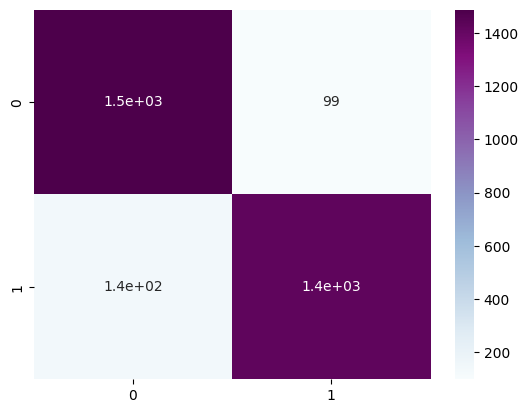

In [73]:
cm = confusion_matrix(y_test,y_pred_dt)
print(cm)
sns.heatmap(cm,cmap="BuPu",annot=True)

In [74]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(Xv_trainTF, y_train)
y_pred_rf = rf_model.predict(Xv_testTF)
print("Random Forest Results")
print(classification_report(y_test, y_pred_rf))


Random Forest Results
              precision    recall  f1-score   support

           0       0.97      0.98      0.98      1586
           1       0.98      0.97      0.98      1564

    accuracy                           0.98      3150
   macro avg       0.98      0.98      0.98      3150
weighted avg       0.98      0.98      0.98      3150



[[1555   31]
 [  43 1521]]


<Axes: >

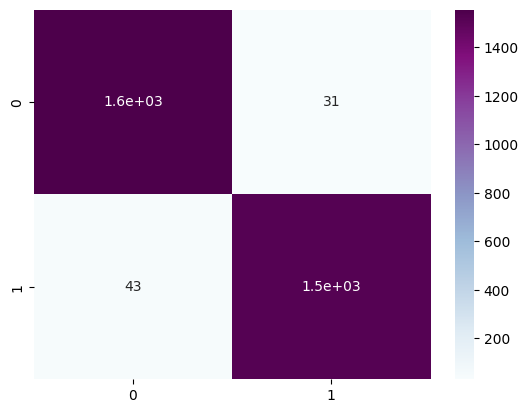

In [75]:
cm = confusion_matrix(y_test,y_pred_rf)
print(cm)
sns.heatmap(cm,cmap="BuPu",annot=True)

In [76]:
svm_model = LinearSVC(random_state=42)
svm_model.fit(Xv_trainTF, y_train)
y_pred_svm = svm_model.predict(Xv_testTF)
print("SVM Results")
print(classification_report(y_test, y_pred_svm))


SVM Results
              precision    recall  f1-score   support

           0       0.98      0.99      0.98      1586
           1       0.99      0.98      0.98      1564

    accuracy                           0.98      3150
   macro avg       0.98      0.98      0.98      3150
weighted avg       0.98      0.98      0.98      3150



[[1569   17]
 [  32 1532]]


<Axes: >

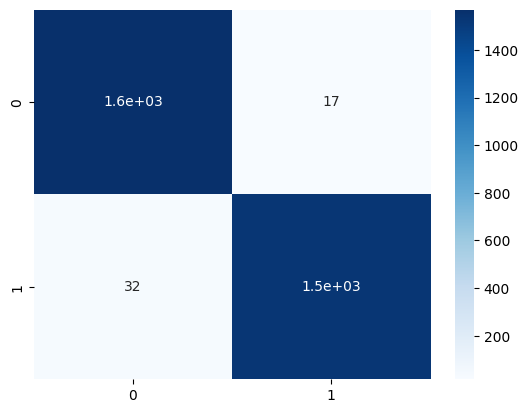

In [77]:
cm = confusion_matrix(y_test,y_pred_svm)  
print(cm)
import seaborn as sns
sns.heatmap(cm,cmap="Blues",annot=True)